# 14 — Event study per individueel aandeel

**Hypothese**: brede indices (SPY/SPX) middelen bedrijfsspecifieke effecten weg.
Als Trump expliciet een bedrijf noemt — "Boeing", "Apple", "Tesla" — verwachten we
een grotere koersreactie op *dat aandeel* dan op de brede markt. 

**Aanpak**:
1. Extraheer bedrijfsvermeldingen uit alle 26.819 posts via een curated
   bedrijf→ticker mapping (`src/features/company_mentions.py`).
2. Download daily koersen per genoemd bedrijf + benchmark (SPY) + sector-ETF.
3. Bereken **market-model abnormal returns**: regresseer aandeelrendement op SPY
   over een estimation window, AR = werkelijk − verwacht. Dit isoleert het
   bedrijfsspecifieke effect van de algemene marktbeweging.
4. Event-study: vergelijk AR_1d en CAR_3d op **mention-dagen** vs. **controle-dagen**
   (zelfde aandeel, dagen zonder Trump-vermelding). Welch t-toets + Bonferroni.
5. Top-movers en interpretatie.

> **Let op**: yfinance vereist internettoegang. Draai deze notebook lokaal.


In [33]:
%load_ext autoreload
%autoreload 2

import sys
import warnings
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from scipy import stats

from src.features.company_mentions import (
    tag_posts, mention_counts, explode_mentions, COMPANIES,
)

sns.set_theme(style="whitegrid", context="notebook")
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
ESTIMATION_WINDOW = 120   # handelsdagen voor market-model schatting
ESTIMATION_GAP = 11       # gap-dagen tussen estimation en event (vermijd leakage)
MIN_POSTS = 30            # minimaal aantal mention-dagen om een bedrijf te bestuderen
print("Setup klaar.")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Setup klaar.


## 1. Posts laden en bedrijven taggen

We gebruiken het volledige Kaggle-archief (feb 2022 – apr 2026, 26.819 posts).
Dit geeft een veel grotere steekproef dan de intraday Iran-analyse (nb10).

In [34]:
posts = pd.read_parquet("../data/raw/posts.parquet")
posts["timestamp_utc"] = pd.to_datetime(posts["timestamp_utc"], utc=True)
posts["post_id"] = posts["post_id"].astype(str)

tagged = tag_posts(posts)
counts = mention_counts(tagged)

print(f"Totaal posts: {len(posts):,}")
print(f"Posts met >=1 bedrijf: {(tagged['n_companies'] > 0).sum():,}")
print()
counts


Totaal posts: 26,819
Posts met >=1 bedrijf: 1,273



,ticker,company,sector_etf,n_posts
0,DJT,Truth Social,XLC,573
1,TWTR,Twitter,XLC,206
2,GOOGL,Google,XLC,173
3,META,Meta,XLC,106
4,TSLA,Tesla,XLY,94
5,AMZN,Amazon,XLY,66
6,AAPL,Apple,XLK,49
7,BA,Boeing,ITA,18
8,DIS,Disney,XLC,13
9,MCD,McDonald's,XLY,11


## 2. Verhandelbaarheids-caveats

Niet elke vermelding is bruikbaar als event:

- **DJT (Trump Media)**: pas beursgenoteerd vanaf **2024-03-26** (SPAC-merger). Posts
  daarvóór die "Truth Social" noemen, kunnen geen koerseffect hebben — die filteren
  we weg.
- **TWTR (Twitter)**: van de beurs gehaald op **2022-10-27** (overname Musk). Alleen
  vermeldingen vóór die datum zijn verhandelbaar.
- Bedrijven met te weinig mention-dagen (`< MIN_POSTS`) hebben onvoldoende power
  voor een t-toets en worden alleen beschrijvend getoond.

In [35]:
# Verhandelbaarheids-windows (None = volledige history)
TRADEABLE_WINDOW = {
    "DJT": (pd.Timestamp("2024-03-26", tz="UTC"), None),
    "TWTR": (None, pd.Timestamp("2022-10-27", tz="UTC")),
}

exploded = explode_mentions(tagged)

def in_tradeable_window(row):
    start, end = TRADEABLE_WINDOW.get(row["ticker"], (None, None))
    ts = row["timestamp_utc"]
    if start is not None and ts < start:
        return False
    if end is not None and ts > end:
        return False
    return True

exploded = exploded[exploded.apply(in_tradeable_window, axis=1)].copy()

tradeable_counts = (
    exploded.groupby(["ticker", "company", "sector_etf"]).size()
    .reset_index(name="n_posts").sort_values("n_posts", ascending=False)
)
study_tickers = tradeable_counts[tradeable_counts["n_posts"] >= MIN_POSTS]["ticker"].tolist()
print("Bedrijven met genoeg mention-dagen voor toetsing (n >= %d):" % MIN_POSTS)
print(study_tickers)
tradeable_counts


Bedrijven met genoeg mention-dagen voor toetsing (n >= 30):
['DJT', 'GOOGL', 'META', 'TSLA', 'AMZN', 'AAPL', 'TWTR']


,ticker,company,sector_etf,n_posts
4,DJT,Truth Social,XLC,491
7,GOOGL,Google,XLC,173
14,META,Meta,XLC,106
19,TSLA,Tesla,XLY,94
1,AMZN,Amazon,XLY,66
0,AAPL,Apple,XLK,49
20,TWTR,Twitter,XLC,36
2,BA,Boeing,ITA,18
3,DIS,Disney,XLC,13
13,MCD,McDonald's,XLY,11


## 3. Marktdata downloaden

Per studie-ticker downloaden we daily OHLCV over de volledige history, plus de
benchmark **SPY** en alle benodigde sector-ETF's.

In [36]:
def download_daily(symbol, start="2022-02-01"):
    df = yf.download(symbol, start=start, interval="1d", progress=False, auto_adjust=True)
    if df.empty:
        return None
    if df.columns.nlevels > 1:
        df.columns = [c.lower() for c in df.columns.get_level_values(0)]
    else:
        df.columns = [c.lower() for c in df.columns]
    df = df.reset_index().rename(columns={"Date": "date", "index": "date"})
    df.columns = [c.lower() for c in df.columns]
    df["date"] = pd.to_datetime(df["date"], utc=True).dt.normalize()
    df["log_return"] = np.log(df["close"] / df["close"].shift(1))
    return df[["date", "close", "volume", "log_return"]]

# Verzamel alle symbolen: studie-tickers + hun sector-ETF's + SPY benchmark
sector_etfs = sorted({c.sector_etf for c in COMPANIES if c.ticker in study_tickers})
symbols = sorted(set(study_tickers) | set(sector_etfs) | {"SPY"})
print("Downloaden:", symbols)

prices = {}
for sym in symbols:
    d = download_daily(sym)
    if d is not None:
        prices[sym] = d
        print(f"  {sym}: {len(d)} dagen ({d['date'].min().date()} -> {d['date'].max().date()})")
    else:
        print(f"  {sym}: GEEN data")


Downloaden: ['AAPL', 'AMZN', 'DJT', 'GOOGL', 'META', 'SPY', 'TSLA', 'TWTR', 'XLC', 'XLK', 'XLY']
  AAPL: 1095 dagen (2022-02-01 -> 2026-06-12)
  AMZN: 1095 dagen (2022-02-01 -> 2026-06-12)
  DJT: 1095 dagen (2022-02-01 -> 2026-06-12)
  GOOGL: 1095 dagen (2022-02-01 -> 2026-06-12)
  META: 1095 dagen (2022-02-01 -> 2026-06-12)


$TWTR: possibly delisted; no timezone found


  SPY: 1095 dagen (2022-02-01 -> 2026-06-12)
  TSLA: 1095 dagen (2022-02-01 -> 2026-06-12)



1 Failed download:
['TWTR']: possibly delisted; no timezone found


  TWTR: GEEN data
  XLC: 1095 dagen (2022-02-01 -> 2026-06-12)
  XLK: 1095 dagen (2022-02-01 -> 2026-06-12)
  XLY: 1095 dagen (2022-02-01 -> 2026-06-12)


## 4. Market-model abnormal returns

Voor elk aandeel schatten we per event-dag het *verwachte* rendement met een
market-model regressie op SPY over het estimation window
`[t-ESTIMATION_WINDOW-GAP, t-GAP]` (gap voorkomt dat het event zelf de schatting
beïnvloedt):

$$r_{i,t} = \alpha_i + \beta_i \, r_{SPY,t} + \varepsilon_{i,t}, \quad
AR_{i,t} = r_{i,t} - (\hat\alpha_i + \hat\beta_i \, r_{SPY,t})$$

De AR is per definitie al markt-gecorrigeerd, dus het *bedrijfsspecifieke* effect.

In [37]:
def compute_market_model_ar(stock_df, market_df,
                             est_window=ESTIMATION_WINDOW, gap=ESTIMATION_GAP):
    """Voeg market-model abnormal return per dag toe aan stock_df."""
    m = stock_df.merge(
        market_df[["date", "log_return"]].rename(columns={"log_return": "mkt_ret"}),
        on="date", how="left",
    ).sort_values("date").reset_index(drop=True)
    ar = np.full(len(m), np.nan)
    for i in range(len(m)):
        lo, hi = i - gap - est_window, i - gap
        if lo < 0:
            continue
        est = m.iloc[lo:hi][["log_return", "mkt_ret"]].dropna()
        if len(est) < est_window * 0.6:
            continue
        beta, alpha = np.polyfit(est["mkt_ret"], est["log_return"], 1)
        expected = alpha + beta * m.loc[i, "mkt_ret"]
        ar[i] = m.loc[i, "log_return"] - expected
    m["ar"] = ar
    # CAR over [t, t+2] (3 handelsdagen)
    m["car_3d"] = m["ar"] + m["ar"].shift(-1) + m["ar"].shift(-2)
    return m

spy = prices["SPY"]
ar_tables = {}
for tkr in study_tickers:
    if tkr in prices:
        ar_tables[tkr] = compute_market_model_ar(prices[tkr], spy)
        n_valid = ar_tables[tkr]["ar"].notna().sum()
        print(f"{tkr}: {n_valid} dagen met geldige AR")


DJT: 964 dagen met geldige AR
GOOGL: 964 dagen met geldige AR
META: 964 dagen met geldige AR
TSLA: 964 dagen met geldige AR
AMZN: 964 dagen met geldige AR
AAPL: 964 dagen met geldige AR


## 5. Event-study per bedrijf

Voor elk bedrijf koppelen we elke mention-post aan de eerstvolgende handelsdag
(post in het weekend → maandag). De **mention-dagen** vergelijken we met de
**controle-dagen** van hetzelfde aandeel (alle handelsdagen zonder vermelding).

In plaats van een parametrische Welch t-toets schatten we het verschil via
**bootstrap-resampling** (cursusmodule 04 "Resampling"): we trekken 10.000 keer
met teruglegging uit beide groepen en lezen een 95%-confidence-interval af op
het gemiddelde verschil. Een CI dat 0 uitsluit is het bootstrap-equivalent van
"significant" — zonder aanname van normaliteit of gelijke varianties.

In [38]:
from src.evaluation.bootstrap import bootstrap_diff_bp

def align_posts_to_trading_day(post_times, trading_dates):
    """Map elke post naar de eerstvolgende handelsdag (>= post-datum)."""
    td = pd.Series(sorted(trading_dates))
    out = []
    for ts in post_times:
        d = ts.normalize()
        nxt = td[td >= d]
        out.append(nxt.iloc[0] if len(nxt) else pd.NaT)
    return pd.Series(out)

results = []
event_detail = {}
for tkr in study_tickers:
    if tkr not in ar_tables:
        continue
    art = ar_tables[tkr].copy()
    trading_dates = art["date"].tolist()
    post_times = exploded[exploded["ticker"] == tkr]["timestamp_utc"]
    mention_days = set(align_posts_to_trading_day(post_times, trading_dates).dropna())
    art["is_mention"] = art["date"].isin(mention_days)
    valid = art.dropna(subset=["ar"])
    event_detail[tkr] = valid

    for metric, col in [("AR_1d", "ar"), ("CAR_3d", "car_3d")]:
        sub = valid.dropna(subset=[col])
        m = sub[sub["is_mention"]][col]
        c = sub[~sub["is_mention"]][col]
        if len(m) < 10 or len(c) < 10:
            continue
        b = bootstrap_diff_bp(m, c, stat=np.mean)   # bootstrap i.p.v. t-toets
        results.append({
            "ticker": tkr, "metric": metric, "n_mention": len(m),
            "diff_bp": b["obs_diff_bp"], "ci_low_bp": b["ci_low_bp"],
            "ci_high_bp": b["ci_high_bp"], "excludes_zero": b["excludes_zero"],
            "p_boot": b["p_boot"],
        })

res = pd.DataFrame(results).sort_values("diff_bp")
res.round(1)


,ticker,metric,n_mention,diff_bp,ci_low_bp,ci_high_bp,excludes_zero,p_boot
7,TSLA,CAR_3d,52,-176.0,-359.4,16.9,False,0.1
1,DJT,CAR_3d,217,-157.7,-307.0,-11.5,True,0.0
6,TSLA,AR_1d,52,-115.5,-228.9,-5.7,True,0.0
3,GOOGL,CAR_3d,127,-38.4,-94.7,17.2,False,0.2
0,DJT,AR_1d,217,-14.2,-95.7,67.5,False,0.7
4,META,AR_1d,79,-9.7,-49.3,29.2,False,0.6
2,GOOGL,AR_1d,127,-7.9,-37.1,19.6,False,0.6
11,AAPL,CAR_3d,35,-4.6,-106.1,104.2,False,0.9
10,AAPL,AR_1d,35,-3.6,-62.2,60.1,False,0.9
8,AMZN,AR_1d,50,22.0,-20.0,65.0,False,0.3


## 6. Inferentie via confidence intervals (geen Bonferroni nodig)

We toetsen meerdere bedrijven × 2 metrieken. Bij p-waarden zou dit een
Bonferroni-correctie vereisen. Door in plaats daarvan **bootstrap-confidence-
intervals** te rapporteren, vervalt die noodzaak: we doen geen formele
null-hypothese-toetsen meer, maar lezen per effect af of het 95%-CI nul
uitsluit. Hieronder de effecten waarvoor dat geldt.

In [39]:
sig = res[res["excludes_zero"]].copy()
print(f"Effecten waarvan het 95%-bootstrap-CI 0 uitsluit: {len(sig)} van {len(res)}")
print("(bootstrap-equivalent van 'significant' — geen multiple-testing-correctie nodig)")
sig.round(1)


Effecten waarvan het 95%-bootstrap-CI 0 uitsluit: 2 van 12
(bootstrap-equivalent van 'significant' — geen multiple-testing-correctie nodig)


,ticker,metric,n_mention,diff_bp,ci_low_bp,ci_high_bp,excludes_zero,p_boot
1,DJT,CAR_3d,217,-157.7,-307.0,-11.5,True,0.0
6,TSLA,AR_1d,52,-115.5,-228.9,-5.7,True,0.0


## 7. Top-movers: individuele mention-dagen met grootste bedrijfsspecifieke beweging

In [40]:
top_rows = []
for tkr, valid in event_detail.items():
    sub = valid[valid["is_mention"]].copy()
    sub["abs_ar"] = sub["ar"].abs()
    sub["ticker"] = tkr
    top_rows.append(sub.nlargest(3, "abs_ar")[["ticker", "date", "ar", "car_3d"]])

top = pd.concat(top_rows).sort_values("ar", key=lambda s: s.abs(), ascending=False)
top["ar_bp"] = top["ar"] * 1e4
top["car_3d_bp"] = top["car_3d"] * 1e4
top[["ticker", "date", "ar_bp", "car_3d_bp"]].head(15)


,ticker,date,ar_bp,car_3d_bp
614,DJT,2024-07-15 00:00:00+00:00,2649.433131,1560.346461
552,DJT,2024-04-15 00:00:00+00:00,-1999.230586,-2155.376289
600,DJT,2024-06-24 00:00:00+00:00,1883.502762,3279.170158
838,TSLA,2025-06-05 00:00:00+00:00,-1430.959269,-869.623822
777,TSLA,2025-03-10 00:00:00+00:00,-963.698053,177.666708
217,TSLA,2022-12-12 00:00:00+00:00,-845.350116,-1504.934654
755,GOOGL,2025-02-05 00:00:00+00:00,-806.850830,-1065.121950
256,GOOGL,2023-02-08 00:00:00+00:00,-645.668051,-1029.417993
799,AAPL,2025-04-09 00:00:00+00:00,573.443034,778.804854
188,META,2022-10-31 00:00:00+00:00,-501.884857,-284.697429


## 8. Visualisatie: effect per bedrijf met 95% bootstrap-CI

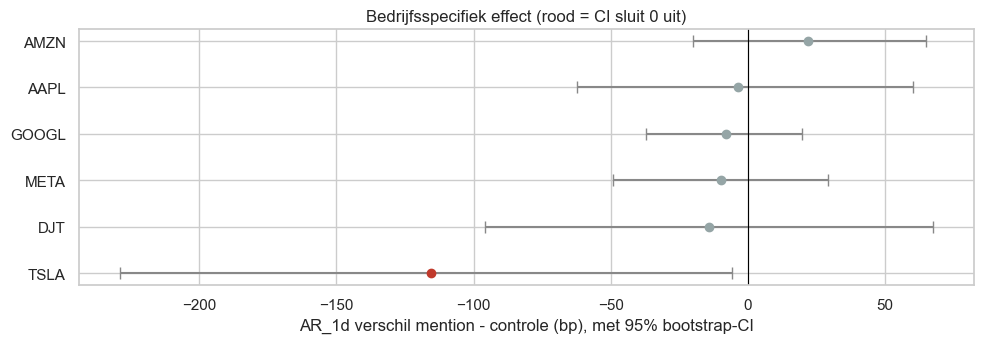

In [41]:
ar_res = res[res["metric"] == "AR_1d"].sort_values("diff_bp")
if len(ar_res):
    fig, ax = plt.subplots(figsize=(10, max(3, 0.6 * len(ar_res))))
    y = np.arange(len(ar_res))
    err = [ar_res["diff_bp"] - ar_res["ci_low_bp"], ar_res["ci_high_bp"] - ar_res["diff_bp"]]
    ax.errorbar(ar_res["diff_bp"], y, xerr=err, fmt="none", ecolor="#888", capsize=4, zorder=2)
    for yi, (d, ex) in enumerate(zip(ar_res["diff_bp"], ar_res["excludes_zero"])):
        ax.plot(d, yi, "o", color="#c0392b" if ex else "#95a5a6", zorder=3)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_yticks(y)
    ax.set_yticklabels(ar_res["ticker"])
    ax.set_xlabel("AR_1d verschil mention - controle (bp), met 95% bootstrap-CI")
    ax.set_title("Bedrijfsspecifiek effect (rood = CI sluit 0 uit)")
    plt.tight_layout()
    plt.savefig("../reports/figures/nb14_ar_per_company.png", dpi=130, bbox_inches="tight")
    plt.show()
else:
    print("Geen resultaten om te plotten.")


## 8b. Robuustheidscheck TSLA — outliers & Trump–Musk-feud

Het TSLA-effect is groot maar mogelijk gedreven door enkele extreme dagen.
Zelfde aanpak als de Hormuz-cluster-check in nb10, nu met bootstrap-CI's: we
laten telkens de zwaarste mention-dagen weg en kijken of het 95%-CI 0 blijft
uitsluiten. Verdwijnt dat → een handvol dagen drijft het effect.

In [42]:
TKR = "TSLA"
valid = event_detail[TKR].dropna(subset=["ar"]).copy()
mention = valid[valid["is_mention"]].copy()
control = valid[~valid["is_mention"]]["ar"]
mention["abs_ar"] = mention["ar"].abs()

rows = []
def add(label, m):
    b = bootstrap_diff_bp(m, control, stat=np.mean)
    rows.append({"scenario": label, "n": b["n_treat"], "diff_bp": b["obs_diff_bp"],
                 "ci_low_bp": b["ci_low_bp"], "ci_high_bp": b["ci_high_bp"],
                 "excludes_zero": b["excludes_zero"]})

add("baseline (alle mention-dagen)", mention["ar"])
for k in (1, 2, 3, 5):
    add(f"drop top-{k} |AR|", mention.drop(mention.nlargest(k, "abs_ar").index)["ar"])

print("Zwaarste mention-dagen (worden in de top-k gedropt):")
print(mention.nlargest(5, "abs_ar")[["date", "ar"]]
      .assign(ar_bp=lambda d: (d["ar"] * 1e4).round(0))[["date", "ar_bp"]].to_string(index=False))
robust = pd.DataFrame(rows)
robust.round(1)


Zwaarste mention-dagen (worden in de top-k gedropt):
                     date   ar_bp
2025-06-05 00:00:00+00:00 -1431.0
2025-03-10 00:00:00+00:00  -964.0
2022-12-12 00:00:00+00:00  -845.0
2025-07-24 00:00:00+00:00  -824.0
2025-03-17 00:00:00+00:00  -717.0


,scenario,n,diff_bp,ci_low_bp,ci_high_bp,excludes_zero
0,baseline (alle mention-dagen),52,-115.5,-228.9,-5.7,True
1,drop top-1 |AR|,51,-89.6,-190.1,11.0,False
2,drop top-2 |AR|,50,-72.0,-169.2,22.9,False
3,drop top-3 |AR|,49,-56.1,-147.5,35.3,False
4,drop top-5 |AR|,47,-25.5,-111.0,60.9,False


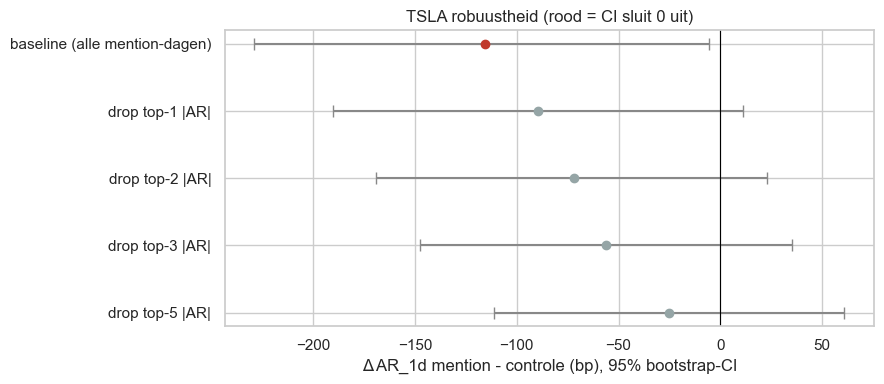

Geexporteerd: data/processed/nb14_event_ar.parquet | 5784 rijen


In [43]:
fig, ax = plt.subplots(figsize=(9, 4))
y = np.arange(len(robust))
err = [robust["diff_bp"] - robust["ci_low_bp"], robust["ci_high_bp"] - robust["diff_bp"]]
ax.errorbar(robust["diff_bp"], y, xerr=err, fmt="none", ecolor="#888", capsize=4, zorder=2)
for yi, (d, ex) in enumerate(zip(robust["diff_bp"], robust["excludes_zero"])):
    ax.plot(d, yi, "o", color="#c0392b" if ex else "#95a5a6", zorder=3)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_yticks(y); ax.set_yticklabels(robust["scenario"]); ax.invert_yaxis()
ax.set_xlabel("Δ AR_1d mention - controle (bp), 95% bootstrap-CI")
ax.set_title("TSLA robuustheid (rood = CI sluit 0 uit)")
plt.tight_layout()
plt.savefig("../reports/figures/nb14_tsla_robustness.png", dpi=130, bbox_inches="tight")
plt.show()

# Export per-dag AR (alle bedrijven) -> reproduceerbaar / verifieerbaar
export = (pd.concat(event_detail, names=["ticker", "row"])
            .reset_index(level="ticker")[["ticker", "date", "ar", "car_3d", "is_mention"]])
export.to_parquet("../data/processed/nb14_event_ar.parquet")
print("Geexporteerd:", "data/processed/nb14_event_ar.parquet", "|", len(export), "rijen")


### 8c. Outlier-robuuste check: mediaan i.p.v. mean (bootstrap)

De mean is gevoelig voor de zware staarten van de AR-verdeling. Een bootstrap-CI
op het **mediaan**-verschil verwijdert die gevoeligheid. Houdt het effect ook hier stand?

In [44]:
TKR = "TSLA"
t = event_detail[TKR].dropna(subset=["ar"])
m = t[t["is_mention"]]["ar"]
c = t[~t["is_mention"]]["ar"]

out = []
for label, stat in [("mean", np.mean), ("median", np.median)]:
    b = bootstrap_diff_bp(m, c, stat=stat)
    out.append({"statistiek": label, "diff_bp": b["obs_diff_bp"],
                "ci_low_bp": b["ci_low_bp"], "ci_high_bp": b["ci_high_bp"],
                "excludes_zero": b["excludes_zero"], "p_boot": b["p_boot"]})
print(f"TSLA mention n={len(m)} | controle n={len(c)} | {(m < 0).mean() * 100:.0f}% van mention-dagen negatief")
pd.DataFrame(out).round(3)


TSLA mention n=52 | controle n=912 | 62% van mention-dagen negatief


,statistiek,diff_bp,ci_low_bp,ci_high_bp,excludes_zero,p_boot
0,mean,-115.472,-228.926,-5.746,True,0.037
1,median,-78.876,-146.446,47.630,False,0.111
